DECISION TREE CLASSIFICATION PROJECT

Dataset loaded successfully!

Dataset Shape:
(50000, 21)

First 5 Rows:
   Gender       City CollegeTier      Stream Specialisation Hostel  \
0  Female      Delhi       Tier3          IT    DataScience    Yes   
1    Male    Chennai       Tier2         ECE             AI    Yes   
2  Female  Hyderabad       Tier3         ECE     Networking     No   
3  Female     Jaipur       Tier3         ECE       Embedded     No   
4    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  CGPA  AttendancePercent  Internships  ...  Workshops  \
0               Yes  6.63               68.3            2  ...        0.0   
1                No  6.40               71.0            1  ...        0.0   
2                No  7.73               75.1            1  ...        2.0   
3                No  9.73               99.2            4  ...        5.0   
4                No  9.01               99.6            2  ...        NaN   

   Cer

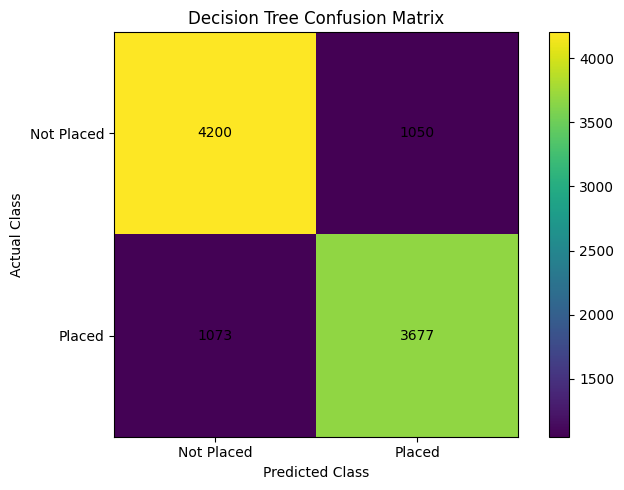


FINAL CONCLUSION

The Placement dataset was used to build a
Decision Tree Classification model.

Target Variable:

0 = Not Placed
1 = Placed

The pipeline performed:

1. Missing Value Imputation
2. Categorical Feature Encoding
3. Decision Tree Classification

The model was evaluated using:

1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. Confusion Matrix

FINAL RESULTS

Accuracy : 0.7877
Precision: 0.7779
Recall   : 0.7741
F1 Score : 0.7760



In [1]:
# ============================================================
# DECISION TREE CLASSIFICATION PROJECT
# Dataset: placement_predict_50k_adjusted(1).csv
# Target: PlacementStatus
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 2. CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

DATA_PATH = "placement_predict_50k_adjusted.csv"


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DECISION TREE CLASSIFICATION PROJECT")
print("=" * 60)

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ------------------------------------------------------------
# 4. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    columns=[
        "PlacementStatus",
        "IsAnomaly"
    ],
    errors="ignore"
)

y = df["PlacementStatus"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


# ------------------------------------------------------------
# 5. IDENTIFY FEATURES
# ------------------------------------------------------------

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("\nNumerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))


# ------------------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# ------------------------------------------------------------
# 7. CREATE PREPROCESSING PIPELINE
# ------------------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 8. CREATE DECISION TREE MODEL
# ------------------------------------------------------------

model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "decision_tree",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=RANDOM_STATE
            )
        )
    ]
)

print("\nDecision Tree Model Created Successfully!")


# ------------------------------------------------------------
# 9. TRAIN MODEL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING DECISION TREE")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")


# ------------------------------------------------------------
# 10. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ------------------------------------------------------------
# 11. MODEL EVALUATION
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


# ------------------------------------------------------------
# 12. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 13. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


# ------------------------------------------------------------
# 14. VISUALIZE CONFUSION MATRIX
# ------------------------------------------------------------

classes = [
    "Not Placed",
    "Placed"
]

plt.figure(figsize=(7, 5))

plt.imshow(cm)
plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Decision Tree Confusion Matrix"
)

for i in range(len(cm)):
    for j in range(len(cm[0])):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 15. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print(f"""
The Placement dataset was used to build a
Decision Tree Classification model.

Target Variable:

0 = Not Placed
1 = Placed

The pipeline performed:

1. Missing Value Imputation
2. Categorical Feature Encoding
3. Decision Tree Classification

The model was evaluated using:

1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. Confusion Matrix

FINAL RESULTS

Accuracy : {accuracy:.4f}
Precision: {precision:.4f}
Recall   : {recall:.4f}
F1 Score : {f1:.4f}
""")

print("=" * 60)